In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt
import polars as pl

from config import PROCESSED_DATA_DIR

from src.graph.eda import SAMLDGraphEDA
from src.graph.pagerank import SAMLDPageRankBaseline

### Methodology

For a directed edge $j \rightarrow i$, weighted PageRank is defined conceptually as

$$
PR(i) = \frac{1-d}{N} + d\sum_{j \rightarrow i} PR(j)
\frac{w_{ji}}{\sum_k w_{jk}},
$$

where $d=0.85$ is the damping factor and $w_{ji}$ is the selected edge weight. The following variants are compared:

- **Unweighted PageRank:** every historical account pair has equal weight
- **Count-weighted PageRank:** repeated transactions receive their full frequency weight
- **Log-count-weighted PageRank:** repeated activity is retained but compressed with log(1+count)
- **Reverse PageRank:** every edge is reversed before scoring, shifting emphasis from receivers toward funding or distribution sources

Simple degree and transaction-activity rankings are included as reference baselines. Personalized PageRank is intentionally deferred until the seed-reachability results below are understood

In [2]:
### initialize validation graph and PageRank baseline
validation_snapshot_dir = PROCESSED_DATA_DIR / 'graph' / 'validation'

# initialize graph EDA
graph_eda = SAMLDGraphEDA(
    snapshot_dir = validation_snapshot_dir
)

# build igraph
validation_graph = graph_eda.build_igraph(
    force_rebuild = False
)

# PageRank baseline - damping factor -> 0.85 as a baseline factor
pagerank_baseline = SAMLDPageRankBaseline(
    graph_eda = graph_eda,
    damping = 0.85
)

print(
    f'Validation vertices: {validation_graph.vcount():,}'
)
print(
    f'Validation edges: {validation_graph.ecount():,}'
)

Validation vertices: 736,925
Validation edges: 761,365


In [3]:
### seed reachability - candidate and target reachability from historical seeds
seed_reachability_summary = pagerank_baseline.get_seed_reachability_summary()

with pl.Config(
    tbl_cols = -1,
    tbl_rows = -1
):
    display(seed_reachability_summary)

reachability_mode,reachable_candidate_count,candidate_coverage,reachable_target_count,target_coverage,unreachable_target_count,reachable_positive_rate,positive_rate_lift
str,i64,f64,i64,f64,i64,f64,f64
"""all_candidates""",731188,1.0,678,1.0,0,0.000927,1.0
"""seed_weak_component""",81125,0.11095,0,0.0,678,0.0,0.0
"""forward_seed_reachable""",63398,0.086705,0,0.0,678,0.0,0.0
"""reverse_seed_reachable""",23091,0.03158,0,0.0,678,0.0,0.0


**How to interpret the reachability table**

- `candidate_coverage` measures how much of the candidate universe is retained by each structural restriction
- `target_coverage` is the proportion of the 678 rankable validation targets that the corresponding direction could theoretically reach from a seed
- `unreachable_target_count` is a structural limitation, not an optimization failure
- `positive_rate_lift` greater than 1 means that the reachable subset concentrates future targets more strongly than the full canidate populations

The weak-component row is an upper bound on either directed propagation result. Comapring forward and reverse target coverage tells us whether suspicious relationships are more accessible along the observed flow of funds or against it. These figures will determine the correct design and evaluation universe for Personalized PageRank in the next phase

**Discussion - observed seed reachability**

The candidate universe contains **731k accounts** and **678 rankable validation targets**. Historical seeds share a weak component with 81125 candidates (11.10%), cacn reach **63398 candidates** in the forward direction **(8.67%)**, anc can reach **23091 candidates** after reversing the edges **(3.16%)**

However, **none of the 678 validation targets** belong to a weak component containing a historical seed. Forward and reverse directed target coverage must therefore also be zero. Since weak-component membership ignores direction, it is the broadest possible seed-connectivity condition; the two directed results cannot recover a target that already fails this condition

This is not an evidence of a reachability-code error. The weak-component implementation uses the persisted node IDs directly, and the forward/reverse flags in the displayed top-ranking table independently show the same separation. The result instead indicates that future suspicious accounts from historical components that are disjoint from previously suspicious accounts under the current temporal split

This finding changes the next modeling decision: **Pesonalized PageRank using only the 5737 historical seeds would assign no propagated mass to any validation target**. It would therefore be inappropriate to evaluate the formulation as though poor target recovery were a tuning failure. A separate within-ring-seed witholding experiment will be needed if Personalized PageRank remains part of the project 

In [4]:
### historical score construction - compute historical reference and PageRank scores
# node score table
node_score_table = pagerank_baseline.build_score_table(
    force_recompute = False
)

# PageRank score columns
pagerank_score_columns = tuple(
    pagerank_baseline.PAGERANK_CONFIGURATIONS
)

# historical scores
pagerank_mass_summary = pl.DataFrame(
    {
        'score_name': pagerank_score_columns,
        'all_node_score_sum': [
            node_score_table
            .get_column(score_name)
            .sum()
        for score_name in pagerank_score_columns
        ]
    }
)

print(
    f'All-node score table shape: {node_score_table.shape}'
)

print(
    f'{"is_rankable_target" in node_score_table.columns}'
)

display(pagerank_mass_summary)

All-node score table shape: (736925, 16)
False


score_name,all_node_score_sum
str,f64
"""pagerank_unweighted""",1.0
"""pagerank_count_weighted""",1.0
"""pagerank_log_count_weighted""",1.0
"""reverse_pagerank_unweighted""",1.0
"""reverse_pagerank_count_weighte…",1.0
"""reverse_pagerank_log_count_wei…",1.0


In [5]:
### score distributions among non-seed candidates
candidate_score_summary = pagerank_baseline.get_score_summary()

with pl.Config(
    tbl_cols = -1,
    tbl_rows = -1
):
    display(candidate_score_summary)

score_name,minimum,mean,median,p95,p99,maximum,zero_share
str,f64,f64,f64,f64,f64,f64,f64
"""out_degree""",0.0,0.94959,0.0,1.0,32.0,59.0,0.683181
"""in_degree""",0.0,1.002092,1.0,1.0,12.0,28.0,0.216839
"""total_directed_degree""",1.0,1.951683,1.0,2.0,43.0,81.0,0.0
"""account_transaction_event_coun…",1.0,18.16619,12.0,16.0,405.0,1089.0,0.0
"""pagerank_unweighted""",8.6738e-7,0.000001,9.9714e-7,0.000002,0.000011,0.000064,0.0
"""pagerank_count_weighted""",8.8374e-7,0.000001,9.8750e-7,0.000002,0.000011,0.000067,0.0
"""pagerank_log_count_weighted""",8.7859e-7,0.000001,9.9745e-7,0.000002,0.000011,0.000065,0.0
"""reverse_pagerank_unweighted""",4.6383e-7,0.000001,4.6383e-7,0.000004,0.000019,0.00009,0.0
"""reverse_pagerank_count_weighte…",4.9040e-7,0.000001,4.9040e-7,0.000003,0.000018,0.000093,0.0


**Score-integrity checks**

Each PageRank vector should sum to approximately **1.0** across all historical nodes. Small floating-point differences are expected. The future target flag must be absent from 'node_score_table'; it is introduced only in the next evaluation step

The score summary indicates whether a method produces a useful spread among candidates. A large zero share is acceptable for degree references but would be unexpected for ordinary PageRank with uniform teleportation. Very concentrated maxima can indicate that dangling receivers or large operational hubs dominate a ranking

**Discussion - score construction and distributions**

All 6 PageRank vectors sum to **1.0**, so the computations satisfy the required probability-mass check. The all-node table has 736k rows and deos not contain `is_rankable_target`, confirming that future validation labels were not used to construct scores

Every ordinary PageRank variant has a zero share of **0.0**. This is expected since uniform teleportation gives every historical node positive probability even when the graph is disconnected. The forward score medians are close to $1.0 * 10^{-6}$, while the upper tail reaches roughly $6.4 * 10^{-5}$ and $6.7 * 10^{-5}$. Reverse PageRank is more concentrated: its median is around $4.6 * 10^{-7}$ to $4.9 * 10^{-7}$ and its maximum is around $9.0 * 10^{-5}$ to $9.3 * 10^{-5}$

This difference is consistent with the graph's directional imbalance. Reversing the edges makes the smaller sender-side population the destination of importance and concentrates more score on a limited number of funding or distribution hubs. The score ranges therefore do not indicate a normalization problem

In [6]:
### candidate ranking and temporal validation - attach validation labels only after the existence of historical scores
# candidate score table
candidate_score_table = pagerank_baseline.build_candidate_score_table()

print(
    f'Candidate count: {candidate_score_table.height:,}'
)
print(
    'Rankable target count: '
    f'{candidate_score_table['is_rankable_target'].sum():,}'
)
print(
    f'Seed rows retained: {candidate_score_table['is_seed'].sum():,}'
)

Candidate count: 731,188
Rankable target count: 678
Seed rows retained: 0


**Discussion - candidate construction**

The evaluation table contains around **731k candidates**, **678 rankable targets** and **zero historical seeds**. These counts match notebook 04_graph_eda.ipynb, confirming that the PageRank methods are compared on the intended and identical candidate universe

This separation is important: known suspicious accounts may receive very high PageRank scores, but rediscovering them is not the temporal discovery objective. Their exclusion prevents artificially optimistic ranking metrics

In [7]:
### evaluate all reference and PageRank rankings
k_values = (
    100,
    500,
    1_000,
    5_000,
    10_000
)

# evaluate PageRank rankings
ranking_evaluation = pagerank_baseline.evaluate_scores(
    k_values = k_values
)

selection_k = 1_000

# evaluate at selection k
evaluation_at_selection_k = (
    ranking_evaluation
    .filter(
        pl.col('requested_k') == selection_k
    )
    .sort(
        [
            'ndcg_at_k',
            'recall_at_k'
        ],
        descending = True
    )
)

with pl.Config(
    tbl_cols = -1,
    tbl_rows = -1
):
    display(evaluation_at_selection_k)

score_name,requested_k,effective_k,hit_count,precision_at_k,recall_at_k,lift_at_k,ndcg_at_k
str,i64,i64,i64,f64,f64,f64,f64
"""pagerank_unweighted""",1000,1000,51,0.051,0.075221,55.000867,0.077829
"""pagerank_log_count_weighted""",1000,1000,47,0.047,0.069322,50.687074,0.073594
"""pagerank_count_weighted""",1000,1000,42,0.042,0.061947,45.294832,0.067361
"""account_transaction_event_coun…",1000,1000,17,0.017,0.025074,18.333622,0.054193
"""reverse_pagerank_log_count_wei…",1000,1000,18,0.018,0.026549,19.412071,0.020682
"""reverse_pagerank_count_weighte…",1000,1000,18,0.018,0.026549,19.412071,0.020647
"""reverse_pagerank_unweighted""",1000,1000,11,0.011,0.016224,11.862932,0.012704
"""out_degree""",1000,1000,0,0.0,0.0,0.0,0.0
"""in_degree""",1000,1000,0,0.0,0.0,0.0,0.0


**Discussion - ranking quality at k = 1_000**

| Method | Hits | Precision@1,000 | Recall@1,000 | Lift@1,000 | NDCG@1,000 |
|---|---:|---:|---:|---:|---:|
| Unweighted forward PageRank | 51 | 5.10% | 7.52% | 55.00× | 7.78% |
| Log-count forward PageRank | 47 | 4.70% | 6.93% | 50.69× | 7.36% |
| Count-weighted forward PageRank | 42 | 4.20% | 6.19% | 45.30× | 6.74% |
| Transaction activity | 17 | 1.70% | 2.51% | 18.33× | 5.42% |
| Log-count reverse PageRank | 18 | 1.80% | 2.65% | 19.41× | 2.07% |
| Count-weighted reverse PageRank | 18 | 1.80% | 2.65% | 19.41× | 2.06% |
| Unweighted reverse PageRank | 11 | 1.10% | 1.62% | 11.86× | 1.27% |

**Unweighted forward PageRank** is the strongest method at NDCG@k and Recall@k capacity and recovers three times as many targets as the transaction-activity baseline. Forward rankings clearly outperform reverse rankings, suggesting that target accounts are better characterized by receiving importance through the observed flow direction than by behaving as upstream sources

Raw transaction-count weighting reduces performance relative to unweighted PageRank, while log-weighting recovers part of the loss. Counterparty topology is therefore more informative than repeated transaction frequency for this ranking problem; full count weights appear to overemphasize repetitive relationships

In [8]:
### best validation method at each investigation capacity
best_method_by_k = (
    ranking_evaluation
    .sort(
        [
            'requested_k',
            'ndcg_at_k',
            'recall_at_k',
            'score_name'
        ],
        descending = [
            False,
            True,
            True,
            False
        ]
    )
    .group_by(
        'requested_k',
        maintain_order = True
    )
    .first()
)

display(best_method_by_k)

requested_k,score_name,effective_k,hit_count,precision_at_k,recall_at_k,lift_at_k,ndcg_at_k
i64,str,i64,i64,f64,f64,f64,f64
100,"""account_transaction_event_coun…",100,17,0.17,0.025074,183.336224,0.232697
500,"""account_transaction_event_coun…",500,17,0.034,0.025074,36.667245,0.069056
1000,"""pagerank_unweighted""",1000,51,0.051,0.075221,55.000867,0.077829
5000,"""pagerank_log_count_weighted""",5000,95,0.019,0.140118,20.490519,0.120085
10000,"""pagerank_unweighted""",10000,168,0.0168,0.247788,18.117933,0.183869


**Discussion - performance depends on investigation capacity**

The leading method changes with operational capacity:
- At k = 100, transaction activity finds 17 targets: **17.0% precision**, **2.51% recall**, approx. **183x lift**, and **23.27% NDCG**
- At k = 500, transaction activity still finds the same **17 targets**. It is excellent at the very top but contributes no additional targets between 101 and 500
- At k = 1000, unweighted forward PageRank becomes best with **51 targets**
- At k = 5000, log-count forward PageRank leads with **95 targets** and **14.01% recall**
- At k = 10000, unweighted forward PageRank leads again with **168 targets** and **24.78% recall**

There is therefore no universally best ranking independent of review capacity. Transaction activity is compelling for a very small alert queue, while forward PageRank provides broader target recovery as capacity grows. For the next modelling stage, k = 1000 may remain the primary selection, but results at 100, 500, 5000, and 10000 should all be reported

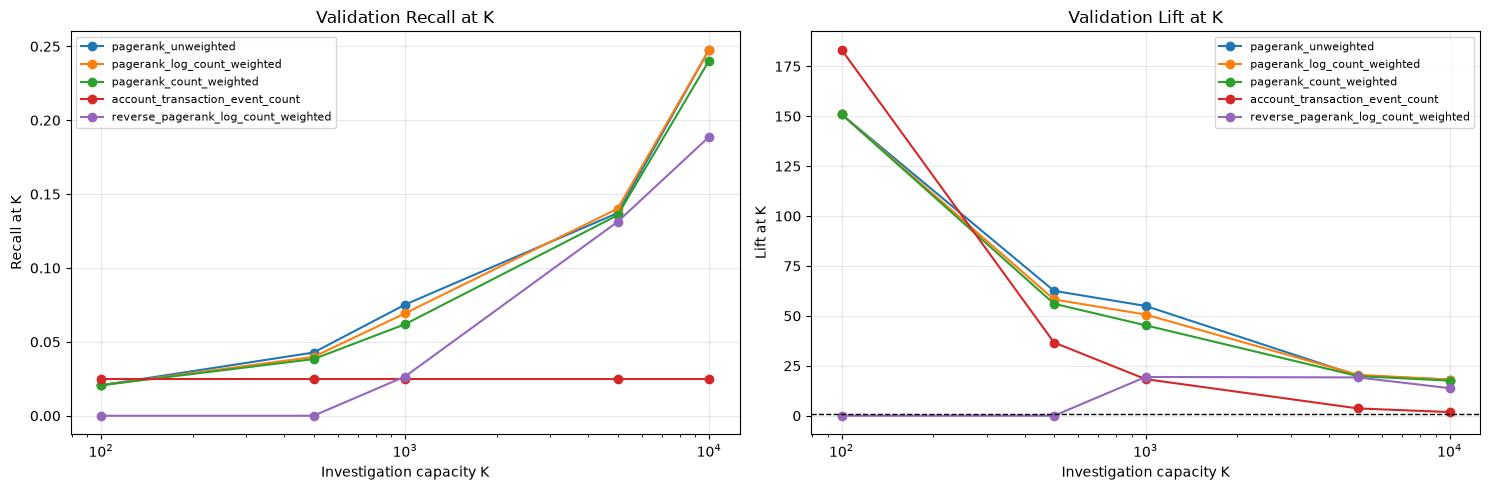

In [9]:
### compare the 5 strongest methods selected at k = 1_000
selected_score_names = (
    evaluation_at_selection_k
    .head(5)
    .get_column('score_name')
    .to_list()
)

fig, axes = plt.subplots(
    nrows = 1,
    ncols = 2,
    figsize = (15, 5)
)

for score_name in selected_score_names:
    method_results = (
        ranking_evaluation
        .filter(
            pl.col('score_name') == score_name
        )
        .sort(
            'effective_k'
        )
    )

    axes[0].plot(
        method_results['effective_k'],
        method_results['recall_at_k'],
        marker = 'o',
        label = score_name
    )

    axes[1].plot(
        method_results['effective_k'],
        method_results['lift_at_k'],
        marker = 'o',
        label = score_name
    )

axes[0].set_title('Validation Recall at K')
axes[0].set_xlabel('Investigation capacity K')
axes[0].set_ylabel('Recall at K')
axes[0].set_xscale('log')

axes[1].set_title('Validation Lift at K')
axes[1].set_xlabel('Investigation capacity K')
axes[1].set_ylabel('Lift at K')
axes[1].set_xscale('log')

axes[1].axhline(
    y = 1.0,
    color = 'black',
    linestyle = '--',
    linewidth = 1
)

for ax in axes:
    ax.legend(fontsize = 8)
    ax.grid(alpha = 0.3)

fig.tight_layout()
plt.show()


**How to compare the rankings**

- **Precision@k** is the proportion of investigated accounts that become suspicious in the validation window
- **Recall@k** is the share of the **678 rankable targets** recovered within the investigation capacity
- **Lift@k** compares precision with random selection from the full candidate population. A lift of 20 means that the selected list is 20 times richer in targets than an equally sized random list
- **NDCG@k** rewards methods that place targets nearer the top, not merely somewhere inside the **first k positions**

No single **k** should determine the conclusion. Prefer a method that performs consistently across plausible investigation capacities. Most importantly, compare every PageRank variant total egree and transaction activity; PageRank demonstrates incremental value only if it improves those simpler baselines

In [10]:
### inspect the leading validation ranking - inspecting candidates from the leading validation method
best_score_name = (
    evaluation_at_selection_k
    .get_column('score_name')
    .item(0)
)

top_ranked_accounts = pagerank_baseline.get_top_ranked_accounts(
    score_column = best_score_name,
    top_n = 25
)

print(
    f'Leading score at k = {selection_k:,}: {best_score_name}'
)

with pl.Config(
    tbl_cols = -1,
    tbl_rows = -1
):
    display(top_ranked_accounts)

Leading score at k = 1,000: pagerank_unweighted


node_id,account,pagerank_unweighted,is_rankable_target,out_degree,in_degree,total_directed_degree,account_transaction_event_count,is_in_seed_weak_component,is_forward_reachable_from_seed,is_reverse_reachable_from_seed
u64,str,f64,bool,u64,u64,u64,u64,bool,bool,bool
518898,"""733362131""",0.000064,false,1,23,24,259,false,false,false
298635,"""4640675219""",0.000064,false,2,23,25,248,false,false,false
307318,"""4745286476""",0.000062,false,1,22,23,257,false,false,false
295193,"""4598137666""",0.000059,false,1,21,22,238,false,false,false
621365,"""8585799732""",0.000059,false,2,21,23,241,false,false,false
150777,"""2838015909""",0.000056,false,1,20,21,233,false,false,false
466796,"""6690980335""",0.000056,false,1,20,21,232,false,false,false
533358,"""7509788619""",0.000055,false,1,1,2,2,false,false,false
306503,"""4735340495""",0.000054,false,1,19,20,218,false,false,false


**Discussion - leading unweighted PageRank accounts**

4 of the displayed top 25 candidates are validation targets, appearing at ranks 13, 19, 24, and 25. That corresponds to **16.00% Precision@25**, compared wih an overall candidate positive rate of only **0.0927%**, altough this additional cutoff was inspected after model comparison and should be treated as descriptive rather than as a pre-selected evaluation metric

Several high-ranking accounts have large in-degree and transaction activity, which is consistent with forward PageRank emphasizing aggregation behavior. A few accounts with total degree only 2 also rank highly; this illustrates that PageRank is recursive and can reward a node receiving importance from an influential counterparty even when its own degree is small

**PageRank baseline conclusion**

The ordinary PAgeRank baseline is successful: forward PageRank substantially improves target concentration over random selection and over simple degree rankings, particularly when the investigation capacity is at least 1000 accounts. Unweighted PageRank is generally strongest, while log-count weighting is competitive at larger capacity and raw count weighting is weaker. Reverse PageRank adds limited value for this target definition

The more consequential result is the complete separation between historical seeds and validation targets. The current temporal experiment supports **global structural ranking**, but it cannot support historical-seed Personalized PageRank because no target shares even a weak component with a seed